<a href="https://colab.research.google.com/github/Naif-ALwaibari/ViT-experiments/blob/main/ViT_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch import nn
import random

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os

os.listdir(f'{path}/chest_xray/chest_xray')

['val', '.DS_Store', 'test', 'train']

In [ ]:
train_path = f'{path}/chest_xray/chest_xray/train'
test_path = f'{path}/chest_xray/chest_xray/test'
val_path = f'{path}/chest_xray/chest_xray/val'

In [ ]:
transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_data = ImageFolder(train_path, transformer)
test_data = ImageFolder(test_path, transformer)
val_data = ImageFolder(val_path, transformer)

In [ ]:
len(train_data), len(test_data), len(val_data)

(5216, 624, 16)

In [ ]:
train_dataloader = DataLoader(train_data, batch_size= 64, shuffle= True)
test_dataloader = DataLoader(test_data, batch_size= 64, shuffle= False)

In [ ]:
image_batch, label_batch = next(iter(train_dataloader))

image, label = image_batch[0], label_batch[0]

image.shape, train_dataloader.dataset.classes[label]

(torch.Size([3, 224, 224]), 'NORMAL')

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

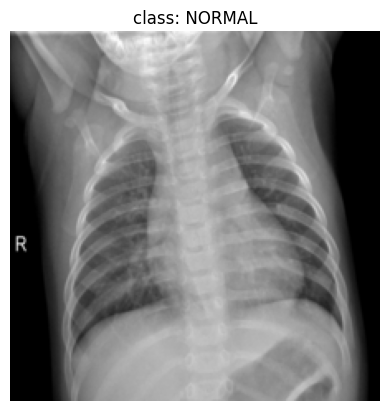

In [ ]:
plt.imshow(image.permute(1, 2, 0))
plt.title(f'class: {train_dataloader.dataset.classes[label]}')
plt.axis(False)

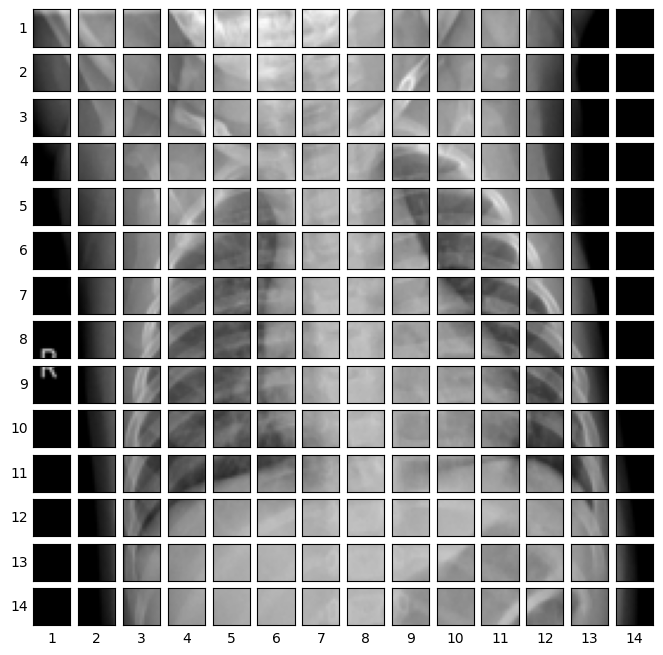

In [ ]:
'''
This cell visualizes the original, manual method of splitting an image into patches as proposed
in the standard Vision Transformer (ViT) paper. Note that in the actual model implementation
later, we will use a more efficient CNN approach (using a Conv2d layer) to extract these patches.
'''

image_permuted = image.permute(1, 2, 0)
image_size = 224
patch_size = 16
assert image_size % patch_size == 0, "Image size must be divisible by patch size"
num_patch = image_size // patch_size

fig, axs = plt.subplots(nrows= num_patch,
                       ncols = num_patch,
                       figsize= (8, 8),
                       sharex=True,
                       sharey=True)

for i, patch_height in enumerate(range(0, image_size, patch_size)):
    for j, patch_width in enumerate(range(0, image_size, patch_size)):
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size,
                                        patch_width:patch_width+patch_size,
                                        :])
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

In [ ]:
image.shape

torch.Size([3, 224, 224])

In [ ]:
'''
This cell demonstrates the efficient, standard approach for splitting an image into patches
using a Convolutional layer (Conv2d). It simultaneously slices the image and projects each
patch into a feature vector (embedding) in a single, highly optimized step.
'''

conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=16,
                   stride=16)

In [ ]:
image_out_of_conv = conv2d(image.unsqueeze(0))
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

Showing random convolutional feature maps from indexes: [630, 460, 278, 353, 111]
630
460
278
353
111


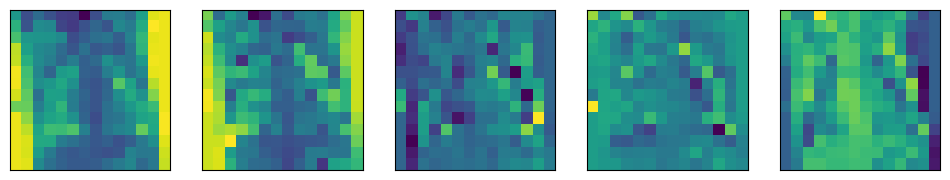

In [ ]:
random_indexes = random.sample(range(0, 768), k=5)
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

for idx, i in enumerate(random_indexes):
    print(i)
    image_conv_feature_map = image_out_of_conv[:, i, :, :]
    axs[idx].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[idx].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [ ]:
flatten = nn.Flatten(start_dim=2)

image_out_of_conv_flattened = flatten(image_out_of_conv)
image_out_of_conv_flattened.shape

torch.Size([1, 768, 196])

In [ ]:
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1)
image_out_of_conv_flattened_reshaped.shape

torch.Size([1, 196, 768])

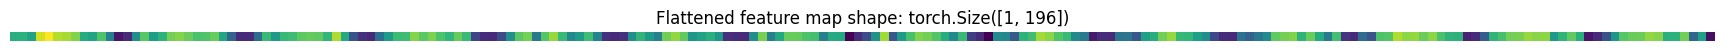

In [ ]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0] # index: (batch_size, number_of_patches, embedding_dimension)

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_chanels = 3, patch_size = 16, embedding_dim = 768):

        super().__init__()

        self.patcher = nn.Conv2d(in_channels=image_chanels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size)

        self.flatten = nn.Flatten(start_dim=2)

    def forward(self, x):

        return self.flatten(self.patcher(x)).permute(0, 2, 1)

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedding_dim = 768, num_heads = 12, attn_dropout = 0):

        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.multiheadAttention = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                        num_heads=num_heads,
                                                        dropout=attn_dropout,
                                                        batch_first=True)
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multiheadAttention(query = x,
                                                 key = x,
                                                 value = x,
                                                 need_weights = False)
        return attn_output

In [ ]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, embedding_dim = 768, mlp_size = 3072, mlp_dropout = 0.1):

        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim, out_features= mlp_size),
            nn.GELU(),
            nn.Dropout(p=mlp_dropout),
            nn.Linear(in_features=mlp_size, out_features= embedding_dim),
            nn.Dropout(p=mlp_dropout)
        )

    def forward(self, x):

        x = self.layer_norm(x)
        x = self.mlp(x)

        return x

In [ ]:
class TransformerEncoder(nn.Module):

    def __init__(self, embedding_dim = 768, mlp_size = 3072, mlp_dropout = 0.1, num_heads = 12, attn_dropout = 0):

        super().__init__()

        self.msa = MultiHeadSelfAttention(embedding_dim=embedding_dim, num_heads=num_heads, attn_dropout=attn_dropout)

        self.mlp = MultiLayerPerceptron(embedding_dim=embedding_dim, mlp_size=mlp_size, mlp_dropout=mlp_dropout)

    def forward(self, x):

        x = self.msa(x) + x

        x = self.mlp(x) + x

        return x

In [ ]:
class ViT(nn.Module):

    def __init__(self,
                 img_size = 224,
                 image_chanels = 3,
                 patch_size = 16,
                 embedding_dim = 768,
                 embedding_dropout = 0.1,
                 num_heads = 12,
                 attn_dropout=0,
                 mlp_size = 3072,
                 mlp_dropout = 0.1,
                 num_transformer_layer = 12):

        super().__init__()

        assert img_size % patch_size == 0,  f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

        self.num_patches = (img_size**2) // patch_size**2

        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim))

        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches + 1, embedding_dim))

        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.patch_embedding = PatchEmbedding(image_chanels=image_chanels, patch_size=patch_size, embedding_dim=embedding_dim)

        self.transformer_encoder = nn.Sequential(*[TransformerEncoder(embedding_dim=embedding_dim,
                                                                      mlp_size=mlp_size,
                                                                      mlp_dropout=mlp_dropout,
                                                                      num_heads=num_heads,
                                                                      attn_dropout=attn_dropout) for _ in range(num_transformer_layer)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim, out_features=2)
        )

    def forward(self, x):

        batch_size = x.shape[0]

        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)

        x = torch.cat((class_token, x), dim=1)

        x = self.position_embedding + x

        x = self.embedding_dropout(x)

        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0, :])

        return x

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ViT().to(device)

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), 0.005)

In [ ]:
def train_step(model, dataloader, loss_fn, optimizer, device):

    model.train()

    train_loss, train_acc = 0, 0

    for x, y in dataloader:

        x, y = x.to(device), y.to(device)
        logit = model(x)
        loss = loss_fn(logit, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        y_pred_class = torch.argmax(logit, dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

def test_step(model, dataloader, loss_fn, device):

    model.eval()

    test_loss, test_acc = 0, 0
    with torch.inference_mode():

        for x, y in dataloader:

            x, y = x.to(device), y.to(device)

            logit = model(x)
            loss = loss_fn(logit, y)

            test_loss += loss.item()
            y_pred_class = torch.argmax(logit, dim=1)
            test_acc += (y_pred_class == y).sum().item() / len(y)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


In [ ]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs, device):

    results = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)

        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

        print(f'Epoch: {epoch+1} | train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | test loss {test_loss:.4f} | test acc: {test_acc:.4f}')

        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)


    return results

In [ ]:
history = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, 10, device)

print('model done training')

Epoch: 1 | train loss: 0.9884 | train acc: 0.6761 | test loss 0.6944 | test acc: 0.6344
Epoch: 2 | train loss: 0.5799 | train acc: 0.7338 | test loss 0.6859 | test acc: 0.6344
Epoch: 3 | train loss: 0.5382 | train acc: 0.7403 | test loss 0.7117 | test acc: 0.6432
Epoch: 4 | train loss: 0.5320 | train acc: 0.7439 | test loss 0.7095 | test acc: 0.6385
Epoch: 5 | train loss: 0.5006 | train acc: 0.7498 | test loss 0.7920 | test acc: 0.6786
Epoch: 6 | train loss: 0.5072 | train acc: 0.7633 | test loss 0.7160 | test acc: 0.6500
Epoch: 7 | train loss: 0.4894 | train acc: 0.7557 | test loss 0.5908 | test acc: 0.6818
Epoch: 8 | train loss: 0.5133 | train acc: 0.7603 | test loss 0.6454 | test acc: 0.6469
Epoch: 9 | train loss: 0.5048 | train acc: 0.7658 | test loss 0.6034 | test acc: 0.6828
Epoch: 10 | train loss: 0.5134 | train acc: 0.7593 | test loss 0.7639 | test acc: 0.6651
model done training


In [ ]:
import timm

model_name = 'vit_base_patch16_224'

pretrained_model = timm.create_model(model_name=model_name, pretrained=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
for param in pretrained_model.parameters():

    param.requires_grad = False

pretrained_model.head = nn.Linear(in_features=768, out_features=2)

pretrained_model.to(device)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
next(pretrained_model.head.parameters()).requires_grad

True

In [ ]:
optimizer_for_pretraind_model = torch.optim.AdamW(pretrained_model.head.parameters(), 0.005)

In [ ]:
pretraind_history = train(pretrained_model, train_dataloader, test_dataloader, optimizer_for_pretraind_model, loss_fn, 10, device)

print('model done training')

Epoch: 1 | train loss: 0.3057 | train acc: 0.8857 | test loss 0.7838 | test acc: 0.7266
Epoch: 2 | train loss: 0.1178 | train acc: 0.9541 | test loss 0.3073 | test acc: 0.8792
Epoch: 3 | train loss: 0.1003 | train acc: 0.9651 | test loss 0.6257 | test acc: 0.7828
Epoch: 4 | train loss: 0.0870 | train acc: 0.9688 | test loss 0.6525 | test acc: 0.7781
Epoch: 5 | train loss: 0.0896 | train acc: 0.9665 | test loss 0.4682 | test acc: 0.8375
Epoch: 6 | train loss: 0.0816 | train acc: 0.9680 | test loss 0.5631 | test acc: 0.8203
Epoch: 7 | train loss: 0.0868 | train acc: 0.9646 | test loss 0.3120 | test acc: 0.8870
Epoch: 8 | train loss: 0.0735 | train acc: 0.9703 | test loss 0.6894 | test acc: 0.8000
Epoch: 9 | train loss: 0.0784 | train acc: 0.9697 | test loss 0.6371 | test acc: 0.8234
Epoch: 10 | train loss: 0.0775 | train acc: 0.9720 | test loss 0.5942 | test acc: 0.8297
model done training


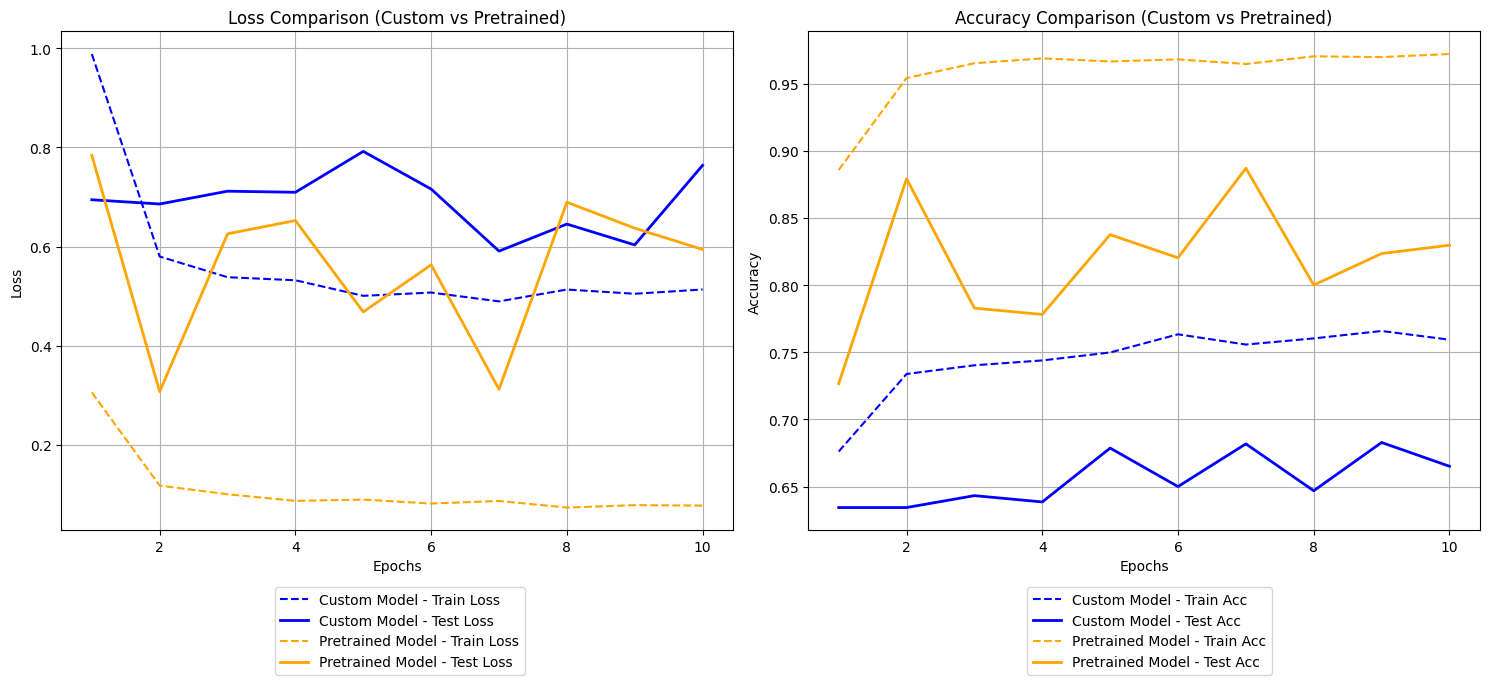

In [ ]:
def plot_model_comparison(history, pretrained_history, epochs=10):
    epochs_range = range(1, epochs + 1)

    fig, axs = plt.subplots(1, 2, figsize=(15, 7))

    axs[0].plot(epochs_range, history['train_loss'], label='Custom Model - Train Loss', color='blue', linestyle='--')
    axs[0].plot(epochs_range, history['test_loss'], label='Custom Model - Test Loss', color='blue', linewidth=2)

    axs[0].plot(epochs_range, pretrained_history['train_loss'], label='Pretrained Model - Train Loss', color='orange', linestyle='--')
    axs[0].plot(epochs_range, pretrained_history['test_loss'], label='Pretrained Model - Test Loss', color='orange', linewidth=2)

    axs[0].set_title('Loss Comparison (Custom vs Pretrained)')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend(bbox_to_anchor=(0.7, -0.10))
    axs[0].grid(True)

    axs[1].plot(epochs_range, history['train_acc'], label='Custom Model - Train Acc', color='blue', linestyle='--')
    axs[1].plot(epochs_range, history['test_acc'], label='Custom Model - Test Acc', color='blue', linewidth=2)

    axs[1].plot(epochs_range, pretrained_history['train_acc'], label='Pretrained Model - Train Acc', color='orange', linestyle='--')
    axs[1].plot(epochs_range, pretrained_history['test_acc'], label='Pretrained Model - Test Acc', color='orange', linewidth=2)

    axs[1].set_title('Accuracy Comparison (Custom vs Pretrained)')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend(bbox_to_anchor=(0.7, -0.10))
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_model_comparison(history, pretraind_history, epochs=10)

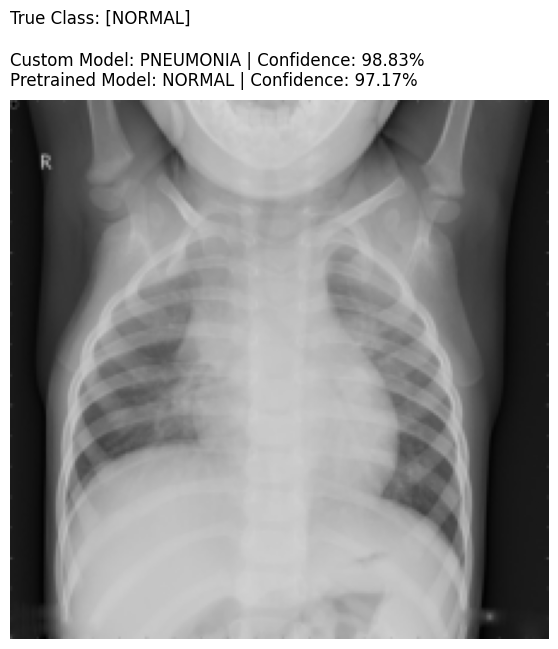

In [ ]:
def plot_random_prediction(model, pretrained_model, val_data, device):

    model.eval()
    pretrained_model.eval()

    random_idx = random.randint(0, len(val_data) - 1)
    img, label = val_data[random_idx]

    class_names = val_data.classes
    true_class = class_names[label]

    img_batch = img.unsqueeze(0).to(device)

    with torch.inference_mode():

        logits_custom = model(img_batch)
        probs_custom = torch.softmax(logits_custom, dim=1)
        conf_custom, pred_idx_custom = torch.max(probs_custom, dim=1)
        pred_class_custom = class_names[pred_idx_custom.item()]

        logits_pre = pretrained_model(img_batch)
        probs_pre = torch.softmax(logits_pre, dim=1)
        conf_pre, pred_idx_pre = torch.max(probs_pre, dim=1)
        pred_class_pre = class_names[pred_idx_pre.item()]

    img_plot = img.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(7, 7))
    plt.imshow(img_plot)
    plt.axis('off')

    title_text = (
        f"True Class: [{true_class}]\n\n"
        f"Custom Model: {pred_class_custom} | Confidence: {conf_custom.item():.2%}\n"
        f"Pretrained Model: {pred_class_pre} | Confidence: {conf_pre.item():.2%}"
    )

    plt.title(title_text, loc='left', fontsize=12, pad=10)
    plt.show()

plot_random_prediction(model, pretrained_model, val_data, device)